In [1]:
# Check R version
R.version.string

# Check current working directory
getwd()

[1] "R version 4.6.1 (2026-06-24)"

[1] "/content"

In [2]:
# Install CRAN packages
install.packages("keras3")
install.packages("tensorflow")

# Install Bioconductor manager
if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager")
}

# Install EBImage
BiocManager::install("EBImage", ask = FALSE, update = FALSE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'EBImage'”


In [4]:
installed.packages()[,c("Package","Version")]

,Package,Version
abind,abind,1.4-8
BiocGenerics,BiocGenerics,0.58.1
BiocManager,BiocManager,1.30.27
BiocVersion,BiocVersion,3.23.1
bitops,bitops,1.1-0
config,config,0.3.2
dotty,dotty,0.1.0
EBImage,EBImage,4.54.0
fftwtools,fftwtools,0.9-11
here,here,1.0.2


In [5]:
system("apt-get update -qq")
system("apt-get install -y libfftw3-dev libfftw3-double3 libfftw3-single3")

In [6]:
install.packages("fftwtools")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [7]:
library(fftwtools)
packageVersion("fftwtools")

[1] ‘0.9.11’

In [8]:
BiocManager::install(
  "EBImage",
  ask = FALSE,
  update = FALSE
)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'EBImage'”


In [9]:
library(EBImage)
packageVersion("EBImage")

[1] ‘4.54.0’

In [10]:
library(keras3)
library(tensorflow)
library(EBImage)


Attaching package: ‘keras3’


The following object is masked from ‘package:EBImage’:

    normalize



Attaching package: ‘tensorflow’


The following objects are masked from ‘package:keras3’:

    set_random_seed, shape




In [11]:
sessionInfo()

R version 4.6.1 (2026-06-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] tensorflow_2.20.0 keras3_1.5.1      EBImage_4.54.0    fftwtools_0.9-11 

loaded via a namespace (and not attached):
 [1] Matrix_1.7-6        jsonlite_2.0.0      compiler_4.6.1

In [12]:
system("apt-get update -qq")
system("apt-get install -y python3.10 python3.10-venv python3.10-dev python3-pip")

In [13]:
system("python3.10 --version")
system("python3.10 -m venv --help")

In [14]:
install_keras(backend = "tensorflow")

Virtual environment 'r-keras' removed.
Using Python: /usr/bin/python3.10
Creating virtual environment 'r-keras' ... 


+ /usr/bin/python3.10 -m venv /root/.virtualenvs/r-keras



Done!
Installing packages: pip, wheel, setuptools


+ /root/.virtualenvs/r-keras/bin/python -m pip install --upgrade pip wheel setuptools



Virtual environment 'r-keras' successfully created.
Using virtual environment 'r-keras' ...


+ /root/.virtualenvs/r-keras/bin/python -m pip install --upgrade --no-user scipy pandas Pillow pydot ipython tensorflow_datasets 'numpy<2'



Using virtual environment 'r-keras' ...


+ /root/.virtualenvs/r-keras/bin/python -m pip install --upgrade --no-user tensorflow-cpu



Using virtual environment 'r-keras' ...


+ /root/.virtualenvs/r-keras/bin/python -m pip install --upgrade --no-user 'keras==3.*'

Finished installing Keras!



In [16]:
library(reticulate)

py_config()

python:         /root/.virtualenvs/r-keras/bin/python
libpython:      /usr/lib/python3.10/config-3.10-x86_64-linux-gnu/libpython3.10.so
pythonhome:     /root/.virtualenvs/r-keras:/root/.virtualenvs/r-keras
version:        3.10.12 (main, Jul 15 2026, 23:40:17) [GCC 11.4.0]
numpy:          /root/.virtualenvs/r-keras/lib/python3.10/site-packages/numpy
numpy_version:  2.2.6
keras:          /root/.virtualenvs/r-keras/lib/python3.10/site-packages/keras

NOTE: Python version was forced by import("keras")

In [17]:
library(tensorflow)

tf$version$VERSION

[1] "2.21.0"

In [18]:
library(keras3)

packageVersion("keras3")

[1] ‘1.5.1’

In [20]:
model_test <- keras_model_sequential() |>
  layer_dense(
    units = 2,
    input_shape = 3
  )

summary(model_test)

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                     │ (None, 2)                │             8 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘
 Total params: 8 (32.00 B)
 Trainable params: 8 (32.00 B)
 Non-trainable params: 0 (0.00 B)


In [23]:
x <- matrix(
  runif(30),
  nrow = 10,
  ncol = 3
)

y <- matrix(
  c(
    1,0,
    0,1,
    1,0,
    0,1,
    1,0,
    0,1,
    1,0,
    0,1,
    1,0,
    0,1
  ),
  nrow = 10,
  byrow = TRUE
)

test_model <- keras_model_sequential() |>
  layer_dense(units = 8, activation = "relu", input_shape = 3) |>
  layer_dense(units = 2, activation = "softmax")

test_model |> compile(
  optimizer = "adam",
  loss = "categorical_crossentropy",
  metrics = "accuracy"
)

test_model |> fit(
  x,
  y,
  epochs = 2,
  verbose = 1
)

In [24]:
cat("R version:", R.version.string, "\n\n")

library(reticulate)
cat("Python configuration:\n")
print(py_config())

cat("\nTensorFlow version:\n")
library(tensorflow)
print(tf$version$VERSION)

cat("\nKeras3 version:\n")
library(keras3)
print(packageVersion("keras3"))

R version: R version 4.6.1 (2026-06-24) 

Python configuration:
python:         /root/.virtualenvs/r-keras/bin/python
libpython:      /usr/lib/python3.10/config-3.10-x86_64-linux-gnu/libpython3.10.so
pythonhome:     /root/.virtualenvs/r-keras:/root/.virtualenvs/r-keras
version:        3.10.12 (main, Jul 15 2026, 23:40:17) [GCC 11.4.0]
numpy:          /root/.virtualenvs/r-keras/lib/python3.10/site-packages/numpy
numpy_version:  2.2.6
keras:          /root/.virtualenvs/r-keras/lib/python3.10/site-packages/keras

NOTE: Python version was forced by import("keras")

TensorFlow version:
[1] "2.21.0"

Keras3 version:
[1] ‘1.5.1’


In [26]:
library(keras3)
library(tensorflow)

cat("TensorFlow:", tf$version$VERSION, "\n")
cat("Keras:", as.character(packageVersion("keras3")), "\n\n")

# Small dummy dataset
set.seed(123)

x <- matrix(
  runif(30),
  nrow = 10,
  ncol = 3
)

y <- matrix(
  c(
    1, 0,
    0, 1,
    1, 0,
    0, 1,
    1, 0,
    0, 1,
    1, 0,
    0, 1,
    1, 0,
    0, 1
  ),
  nrow = 10,
  byrow = TRUE
)

# Create model
test_model <- keras_model_sequential() |>
  layer_dense(
    units = 8,
    activation = "relu",
    input_shape = 3
  ) |>
  layer_dense(
    units = 2,
    activation = "softmax"
  )

# Compile
test_model |> compile(
  optimizer = "adam",
  loss = "categorical_crossentropy",
  metrics = "accuracy"
)

# Train
history_test <- test_model |> fit(
  x,
  y,
  epochs = 2,
  batch_size = 2,
  verbose = 1
)

cat("\nKeras training test completed successfully.\n")

TensorFlow: 2.21.0 
Keras: 1.5.1 


Keras training test completed successfully.


In [28]:
# Check whether EBImage is installed
"EBImage" %in% rownames(installed.packages())

[1] TRUE

In [29]:
library(EBImage)
packageVersion("EBImage")

[1] ‘4.54.0’

In [30]:
system("ldconfig -p | grep fftw")


In [31]:
system("g++ --version | head -1")

In [32]:
library(EBImage)

cat("EBImage loaded successfully!\n")
cat("EBImage version:", as.character(packageVersion("EBImage")), "\n")

EBImage loaded successfully!
EBImage version: 4.54.0 


In [33]:
# Create project directories
dir.create("/content/Lab_4_Image_Classification", showWarnings = FALSE)
dir.create("/content/Lab_4_Image_Classification/data",
           showWarnings = FALSE)
dir.create("/content/Lab_4_Image_Classification/output",
           showWarnings = FALSE)
dir.create("/content/Lab_4_Image_Classification/screenshots",
           showWarnings = FALSE)

setwd("/content/Lab_4_Image_Classification")

getwd()

[1] "/content/Lab_4_Image_Classification"

In [34]:
data_url <- "https://goo.gl/To15db"

download.file(
  data_url,
  destfile = "data/dataset_download",
  mode = "wb"
)

file.info("data/dataset_download")

,size,isdir,mode,mtime,ctime,atime,uid,gid,uname,grname
,<dbl>,<lgl>,<octmode>,<dttm>,<dttm>,<dttm>,<int>,<int>,<chr>,<chr>
data/dataset_download,405187,FALSE,644,2026-08-29 15:48:32,2026-08-29 15:48:32,2026-08-29 15:48:31,0,0,root,root


In [37]:
system("file data/dataset_download")

In [38]:
file.info("data/dataset_download")$size

[1] 405187

In [39]:
# Check whether the downloaded file exists
print(file.exists("data/dataset_download"))

# Show its size
print(file.info("data/dataset_download")$size)

# Read the first few bytes and identify the file
con <- file("data/dataset_download", "rb")
bytes <- readBin(con, "raw", n = 16)
close(con)

print(bytes)

[1] TRUE
[1] 405187
 [1] 3c 21 44 4f 43 54 59 50 45 20 68 74 6d 6c 3e 3c


In [40]:
unlink("data/dataset_download")

cat("Bad dataset download removed.\n")

Bad dataset download removed.


In [41]:
dataset_url <- "https://github.com/AARTI756/23102A0007_R-PROGRAMMING/raw/refs/heads/main/Assignment/Lab_4_Image_Classification/images-20260818T092405Z-1-001.zip"

download.file(
  dataset_url,
  destfile = "data/images.zip",
  mode = "wb"
)

print(file.exists("data/images.zip"))
print(file.info("data/images.zip")$size)

[1] TRUE
[1] 77705


In [42]:
con <- file("data/images.zip", "rb")
bytes <- readBin(con, "raw", n = 4)
close(con)

print(bytes)

[1] 50 4b 03 04


In [43]:
dir.create("data/images", showWarnings = FALSE)

unzip(
  "data/images.zip",
  exdir = "data/images"
)

list.files(
  "data/images",
  recursive = TRUE
)

[1] "images/c1.jpg" "images/c2.jpg" "images/c3.jpg" "images/c4.jpg"
 [5] "images/c5.jpg" "images/c6.jpg" "images/p1.jpg" "images/p2.jpg"
 [9] "images/p3.jpg" "images/p4.jpg" "images/p5.jpg" "images/p6.jpg"

In [44]:
library(keras3)
library(tensorflow)
library(EBImage)

# Project directories
project_dir <- "/content/Lab_4_Image_Classification"
image_dir <- file.path(project_dir, "data")

# Find images recursively
image_files <- list.files(
  image_dir,
  pattern = "\\.(jpg|jpeg|png)$",
  recursive = TRUE,
  full.names = TRUE,
  ignore.case = TRUE
)

# Sort files
image_files <- sort(image_files)

cat("Number of images:", length(image_files), "\n")
print(basename(image_files))

Number of images: 12 
 [1] "c1.jpg" "c2.jpg" "c3.jpg" "c4.jpg" "c5.jpg" "c6.jpg" "p1.jpg" "p2.jpg"
 [9] "p3.jpg" "p4.jpg" "p5.jpg" "p6.jpg"


In [45]:
labels <- ifelse(
  grepl("^p", basename(image_files), ignore.case = TRUE),
  "P",
  "C"
)

image_info <- data.frame(
  Image = basename(image_files),
  Class = labels
)

print(image_info)

    Image Class
1  c1.jpg     C
2  c2.jpg     C
3  c3.jpg     C
4  c4.jpg     C
5  c5.jpg     C
6  c6.jpg     C
7  p1.jpg     P
8  p2.jpg     P
9  p3.jpg     P
10 p4.jpg     P
11 p5.jpg     P
12 p6.jpg     P


In [46]:
table(labels)

labels
C P 
6 6 

In [47]:
images <- lapply(
  image_files,
  readImage
)

cat("Images successfully loaded:", length(images), "\n")

Images successfully loaded: 12 


In [48]:
img1 <- images[[1]]

print(img1)

Image 
  colorMode    : Color 
  storage.mode : double 
  dim          : 308 164 3 
  frames.total : 3 
  frames.render: 1 

imageData(object)[1:5,1:6,1]
          [,1]      [,2]      [,3]      [,4]      [,5]      [,6]
[1,] 0.9529412 0.9529412 0.9529412 0.9529412 0.9529412 0.9529412
[2,] 0.9529412 0.9529412 0.9529412 0.9529412 0.9529412 0.9529412
[3,] 0.9529412 0.9529412 0.9529412 0.9529412 0.9529412 0.9529412
[4,] 0.9529412 0.9529412 0.9529412 0.9529412 0.9529412 0.9529412
[5,] 0.9529412 0.9529412 0.9529412 0.9529412 0.9529412 0.9529412


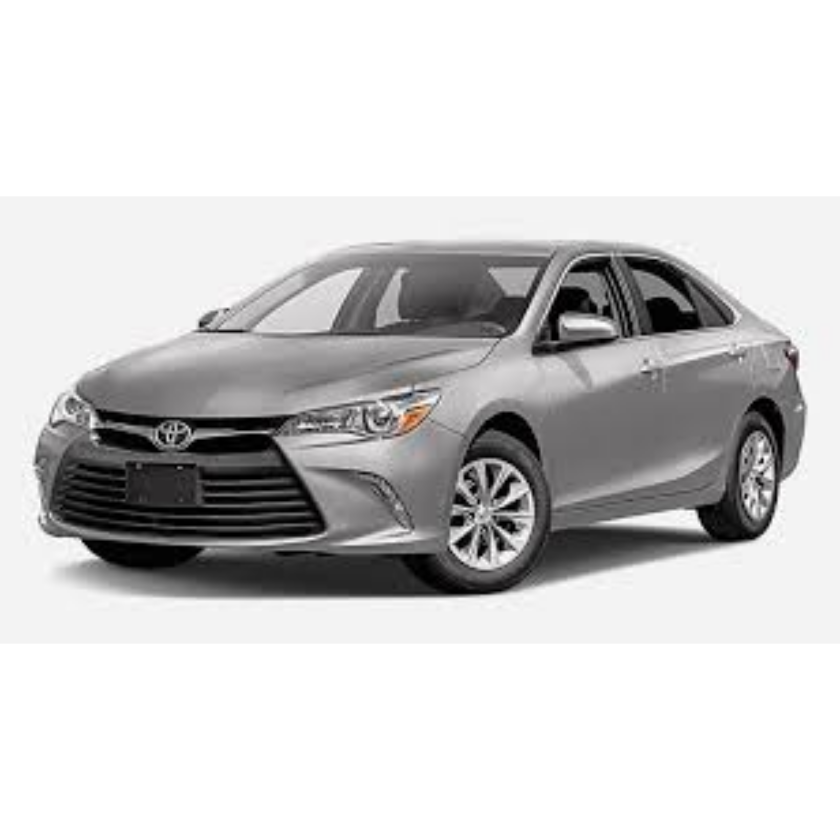

In [49]:
display(img1)

In [50]:
image_dimensions <- lapply(
  images,
  dim
)

for (i in seq_along(image_dimensions)) {
  cat(
    basename(image_files[i]),
    ":",
    paste(image_dimensions[[i]], collapse = " × "),
    "\n"
  )
}

c1.jpg : 308 × 164 × 3 
c2.jpg : 287 × 175 × 3 
c3.jpg : 308 × 164 × 3 
c4.jpg : 276 × 182 × 3 
c5.jpg : 304 × 166 × 3 
c6.jpg : 318 × 159 × 3 
p1.jpg : 281 × 180 × 3 
p2.jpg : 272 × 185 × 3 
p3.jpg : 341 × 148 × 3 
p4.jpg : 318 × 159 × 3 
p5.jpg : 275 × 183 × 3 
p6.jpg : 277 × 182 × 3 


In [51]:
cat("Class distribution:\n")
print(table(labels))

Class distribution:
labels
C P 
6 6 


In [52]:
print(image_info)

    Image Class
1  c1.jpg     C
2  c2.jpg     C
3  c3.jpg     C
4  c4.jpg     C
5  c5.jpg     C
6  c6.jpg     C
7  p1.jpg     P
8  p2.jpg     P
9  p3.jpg     P
10 p4.jpg     P
11 p5.jpg     P
12 p6.jpg     P


In [53]:
resized_images <- lapply(
  images,
  function(img) {
    resize(img, w = 28, h = 28)
  }
)

cat("Resizing completed.\n")

Resizing completed.


In [54]:
for (i in seq_along(resized_images)) {
  cat(
    basename(image_files[i]),
    ":",
    paste(dim(resized_images[[i]]), collapse = " × "),
    "\n"
  )
}

c1.jpg : 28 × 28 × 3 
c2.jpg : 28 × 28 × 3 
c3.jpg : 28 × 28 × 3 
c4.jpg : 28 × 28 × 3 
c5.jpg : 28 × 28 × 3 
c6.jpg : 28 × 28 × 3 
p1.jpg : 28 × 28 × 3 
p2.jpg : 28 × 28 × 3 
p3.jpg : 28 × 28 × 3 
p4.jpg : 28 × 28 × 3 
p5.jpg : 28 × 28 × 3 
p6.jpg : 28 × 28 × 3 


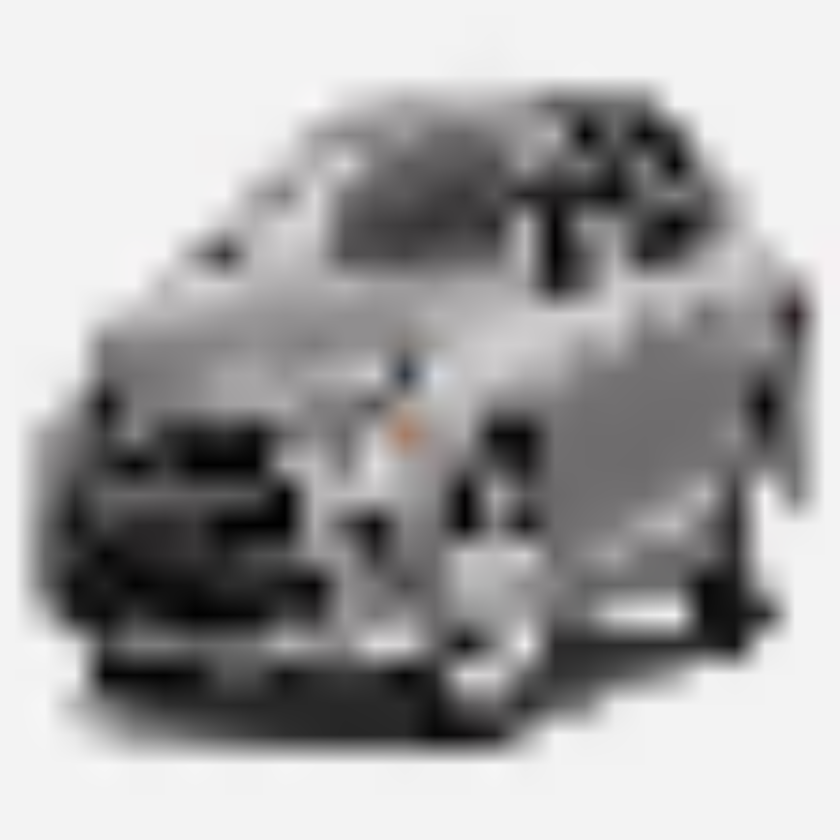

In [55]:
display(resized_images[[1]])

In [56]:
image_vectors <- lapply(
  resized_images,
  function(img) {
    as.numeric(img)
  }
)

In [57]:
length(image_vectors[[1]])

[1] 2352

In [58]:
X <- do.call(
  rbind,
  image_vectors
)

dim(X)

[1]   12 2352

In [59]:
range(X)
if (max(X) > 1) {
  X <- X / 255
}

range(X)

[1] 0 1

[1] 0 1

In [60]:
y_numeric <- ifelse(labels == "P", 1, 0)

print(y_numeric)

 [1] 0 0 0 0 0 0 1 1 1 1 1 1


In [61]:
y <- to_categorical(
  y_numeric,
  num_classes = 2
)

print(y)

      [,1] [,2]
 [1,]    1    0
 [2,]    1    0
 [3,]    1    0
 [4,]    1    0
 [5,]    1    0
 [6,]    1    0
 [7,]    0    1
 [8,]    0    1
 [9,]    0    1
[10,]    0    1
[11,]    0    1
[12,]    0    1


In [62]:
dim(y)

[1] 12  2

In [63]:
set.seed(123)

indices <- sample(
  seq_len(nrow(X))
)

train_indices <- indices[1:10]
test_indices <- indices[11:12]

In [64]:
X_train <- X[train_indices, , drop = FALSE]
X_test  <- X[test_indices, , drop = FALSE]

y_train <- y[train_indices, , drop = FALSE]
y_test  <- y[test_indices, , drop = FALSE]

In [65]:
cat("Training X:", dim(X_train), "\n")
cat("Testing X :", dim(X_test), "\n")

cat("Training y:", dim(y_train), "\n")
cat("Testing y :", dim(y_test), "\n")

Training X: 10 2352 
Testing X : 2 2352 
Training y: 10 2 
Testing y : 2 2 


In [66]:
cat("TRAINING IMAGES\n")
print(image_info[train_indices, ])

cat("\nTESTING IMAGES\n")
print(image_info[test_indices, ])

TRAINING IMAGES
    Image Class
3  c3.jpg     C
12 p6.jpg     P
10 p4.jpg     P
2  c2.jpg     C
6  c6.jpg     C
11 p5.jpg     P
5  c5.jpg     C
4  c4.jpg     C
9  p3.jpg     P
8  p2.jpg     P

TESTING IMAGES
   Image Class
1 c1.jpg     C
7 p1.jpg     P


In [67]:
model <- keras_model_sequential() |>
  layer_dense(
    units = 256,
    activation = "relu",
    input_shape = 2352
  ) |>
  layer_dense(
    units = 128,
    activation = "relu"
  ) |>
  layer_dense(
    units = 2,
    activation = "softmax"
  )

In [68]:
summary(model)

Model: "sequential_4"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                   │ (None, 256)              │       602,368 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_8 (Dense)                   │ (None, 128)              │        32,896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_9 (Dense)                   │ (None, 2)                │           258 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘
 Total params: 635,522 (2.42 MB)
 Trainable params: 635,522 (2.42 MB)
 Non-trainable params: 0 (0.00 B)


In [69]:
model |> compile(
  optimizer = "adam",
  loss = "categorical_crossentropy",
  metrics = "accuracy"
)

In [70]:
cat("Model compiled successfully.\n")

Model compiled successfully.


In [71]:
history <- model |> fit(
  X_train,
  y_train,
  epochs = 30,
  batch_size = 2,
  verbose = 1
)

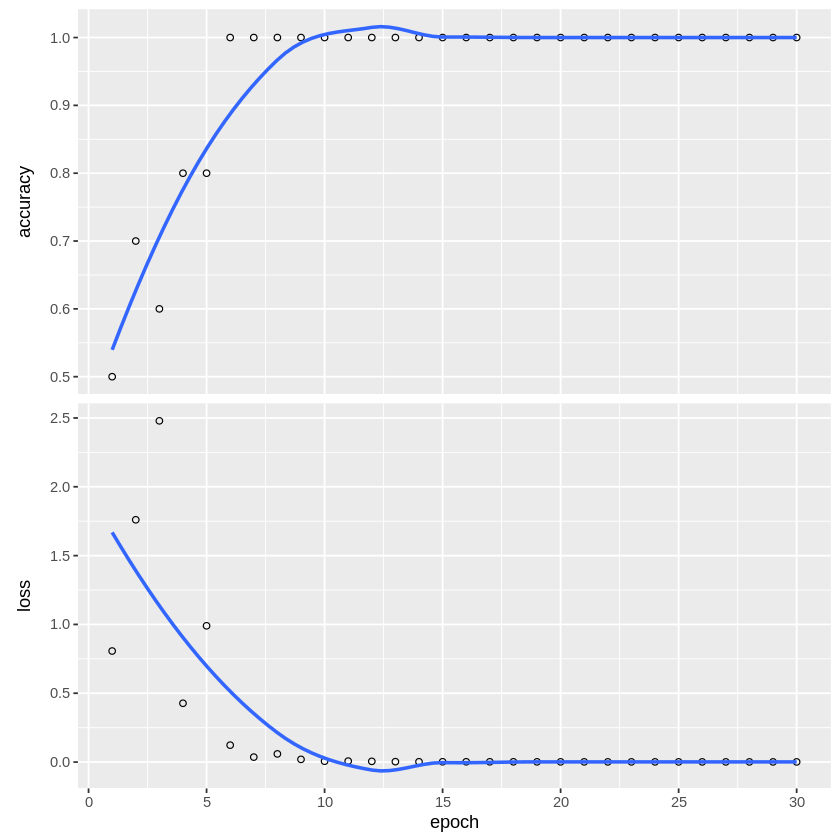

In [72]:
plot(history)

In [73]:
train_results <- model |> evaluate(
  X_train,
  y_train,
  verbose = 0
)

print(train_results)

$accuracy
[1] 1

$loss
[1] 0.001101346



In [74]:
train_accuracy <- as.numeric(
  train_results["accuracy"]
)

cat(
  "Training Accuracy:",
  round(train_accuracy * 100, 2),
  "%\n"
)

Training Accuracy: 100 %


In [75]:
test_results <- model |> evaluate(
  X_test,
  y_test,
  verbose = 0
)

print(test_results)

test_accuracy <- as.numeric(
  test_results["accuracy"]
)

cat(
  "Testing Accuracy:",
  round(test_accuracy * 100, 2),
  "%\n"
)

$accuracy
[1] 1

$loss
[1] 0.001795183

Testing Accuracy: 100 %


In [76]:
predictions <- model |> predict(X_test)

print(predictions)

            [,1]         [,2]
[1,] 0.999485612 0.0005143735
[2,] 0.003071139 0.9969288707


In [77]:
predicted_numeric <- max.col(predictions) - 1
actual_numeric <- max.col(y_test) - 1

predicted_labels <- ifelse(
  predicted_numeric == 1,
  "P",
  "C"
)

actual_labels <- ifelse(
  actual_numeric == 1,
  "P",
  "C"
)

In [78]:
prediction_results <- data.frame(
  Image = basename(image_files[test_indices]),
  Actual = actual_labels,
  Predicted = predicted_labels
)

print(prediction_results)

   Image Actual Predicted
1 c1.jpg      C         C
2 p1.jpg      P         P


In [79]:
confusion_matrix <- table(
  Actual = actual_labels,
  Predicted = predicted_labels
)

print(confusion_matrix)

      Predicted
Actual C P
     C 1 0
     P 0 1


In [80]:
cm_accuracy <- sum(
  diag(confusion_matrix)
) / sum(confusion_matrix)

cat(
  "Confusion Matrix Accuracy:",
  round(cm_accuracy * 100, 2),
  "%\n"
)

Confusion Matrix Accuracy: 100 %


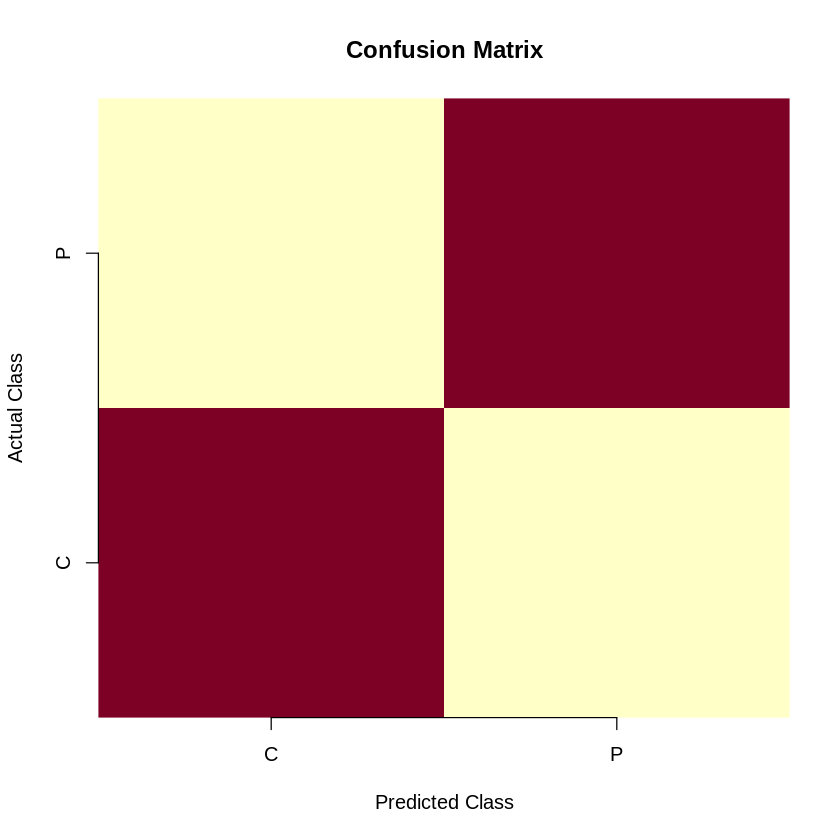

In [81]:
image(
  x = seq_len(ncol(confusion_matrix)),
  y = seq_len(nrow(confusion_matrix)),
  z = t(confusion_matrix),
  axes = FALSE,
  xlab = "Predicted Class",
  ylab = "Actual Class",
  main = "Confusion Matrix"
)

axis(
  1,
  at = seq_len(ncol(confusion_matrix)),
  labels = colnames(confusion_matrix)
)

axis(
  2,
  at = seq_len(nrow(confusion_matrix)),
  labels = rownames(confusion_matrix)
)

In [82]:
final_results <- data.frame(
  Metric = c(
    "Total Images",
    "Class C Images",
    "Class P Images",
    "Training Images",
    "Testing Images",
    "Image Width",
    "Image Height",
    "Channels",
    "Features per Image",
    "Hidden Layer 1",
    "Hidden Layer 2",
    "Output Classes",
    "Epochs",
    "Training Accuracy",
    "Testing Accuracy"
  ),
  Value = c(
    12,
    sum(labels == "C"),
    sum(labels == "P"),
    nrow(X_train),
    nrow(X_test),
    28,
    28,
    3,
    2352,
    256,
    128,
    2,
    30,
    paste0(round(train_accuracy * 100, 2), "%"),
    paste0(round(test_accuracy * 100, 2), "%")
  )
)

print(final_results)

               Metric Value
1        Total Images    12
2      Class C Images     6
3      Class P Images     6
4     Training Images    10
5      Testing Images     2
6         Image Width    28
7        Image Height    28
8            Channels     3
9  Features per Image  2352
10     Hidden Layer 1   256
11     Hidden Layer 2   128
12     Output Classes     2
13             Epochs    30
14  Training Accuracy  100%
15   Testing Accuracy  100%


In [83]:
output_dir <- file.path(project_dir, "output")

write.csv(
  final_results,
  file.path(output_dir, "final_results.csv"),
  row.names = FALSE
)

write.csv(
  prediction_results,
  file.path(output_dir, "predictions.csv"),
  row.names = FALSE
)

write.csv(
  as.data.frame(confusion_matrix),
  file.path(output_dir, "confusion_matrix.csv"),
  row.names = FALSE
)

saveRDS(
  history,
  file.path(output_dir, "training_history.rds")
)

cat("Outputs saved successfully.\n")

Outputs saved successfully.


In [84]:
list.files(
  project_dir,
  recursive = TRUE
)

[1] "data/images.zip"             "data/images/images/c1.jpg"  
 [3] "data/images/images/c2.jpg"   "data/images/images/c3.jpg"  
 [5] "data/images/images/c4.jpg"   "data/images/images/c5.jpg"  
 [7] "data/images/images/c6.jpg"   "data/images/images/p1.jpg"  
 [9] "data/images/images/p2.jpg"   "data/images/images/p3.jpg"  
[11] "data/images/images/p4.jpg"   "data/images/images/p5.jpg"  
[13] "data/images/images/p6.jpg"   "output/confusion_matrix.csv"
[15] "output/final_results.csv"    "output/predictions.csv"     
[17] "output/training_history.rds"